# Baseline Unet solution

## Setup

### Imports

In [27]:
import os
import shutil
from functools import partial

import torch
import numpy as np
import torchvision
import pandas as pd
from matplotlib import cm
import plotly.express as px
import matplotlib.pyplot as plt

## Data loading

### Format images into Tensors

In [2]:
def load_imgs_as_tensor(imgs_parent_dir: str) -> torch.Tensor:
    imgs_filenames = sorted(os.listdir(imgs_parent_dir))
    imgs_buffer = torch.empty((len(imgs_filenames), 256, 256), dtype=torch.uint8)
    for img_i, img_filename in enumerate(imgs_filenames):
        img_path = os.path.join(imgs_parent_dir, img_filename)
        imgs_buffer[img_i] = torchvision.io.decode_image(img_path)[0]
    return imgs_buffer

x_train = load_imgs_as_tensor("dataset/raw/x-train")
x_test = load_imgs_as_tensor("dataset/raw/x-test")

In [3]:
print("First 10 train images:")
display(px.imshow(x_train.numpy()[:10], color_continuous_scale="rainbow", facet_col=0, facet_col_wrap=5))
print("Last 10 train images:")
display(px.imshow(x_train.numpy()[-10:], color_continuous_scale="rainbow", facet_col=0, facet_col_wrap=5))

First 10 train images:


Last 10 train images:


In [4]:
print("First 10 test images:")
display(px.imshow(x_test.numpy()[:10], color_continuous_scale="rainbow", facet_col=0, facet_col_wrap=5))
print("Last 10 test images:")
display(px.imshow(x_test.numpy()[-10:], color_continuous_scale="rainbow", facet_col=0, facet_col_wrap=5))

First 10 test images:


Last 10 test images:


In [5]:
y_train_np = (
    pd
    .read_csv("dataset/raw/y-train.csv", index_col=0)
    .astype("uint8")
    .T
    .values
    .reshape(-1, 256, 256)
)
y_train = torch.from_numpy(y_train_np)

In [6]:
px.imshow(y_train[0].numpy())

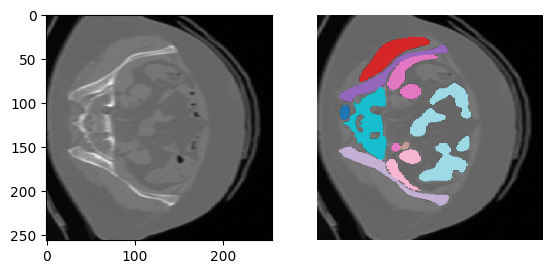

In [7]:
def plot_slice_seg(slice_image: np.ndarray, seg: np.ndarray):
    fig, axes = plt.subplots(1, 2)
    axes[0].imshow(slice_image, cmap="gray")
    axes[1].imshow(slice_image, cmap="gray")
    seg_masked = np.ma.masked_where(seg == 0, seg)
    axes[1].imshow(seg_masked, cmap="tab20")
    plt.axis("off")

plot_slice_seg(
    x_train[0].numpy(),
    y_train.numpy()[0],
)

In [30]:
def format_raw_dataset_and_save_as_pt_files():
    shutil.rmtree("dataset/formatted", ignore_errors=True)
    os.makedirs("dataset/formatted", exist_ok=True)
    torch.save(
        load_imgs_as_tensor("dataset/raw/x-train"),
        "dataset/formatted/x-train.pt",
    )
    torch.save(
        load_imgs_as_tensor("dataset/raw/x-test"),
        "dataset/formatted/x-test.pt",
    )
    y_train_np = (
        pd
        .read_csv("dataset/raw/y-train.csv", index_col=0)
        .astype("uint8")
        .T
        .values
        .reshape(-1, 256, 256)
    )
    y_train = torch.from_numpy(y_train_np)
    torch.save(y_train, "dataset/formatted/y-train.pt")

format_raw_dataset_and_save_as_pt_files()

### torch dataset creation

In [ ]:
# Take the first 800 (the ones with labels) images
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
N_LABELED_SAMPLES = 800
BATCH_SIZE = 64
load_tensor = partial(torch.load, weights_only=True, map_location=device)
x_train = load_tensor("dataset/formatted/y-train.pt")[:N_LABELED_SAMPLES]
y_train = load_tensor("dataset/formatted/x-train.pt")[:N_LABELED_SAMPLES]
train_ds = torch.utils.data.TensorDataset(x_train, y_train)
train_dl = torch.utils.data.DataLoader(
    train_ds,
    BATCH_SIZE,
    pin_memory=True,
)

In [34]:
mean_train = x_train.float().mean()
std_train = x_train.float().std()
print("mean_train:", mean_train, "std_train:", std_train)

mean_train: tensor(61.2064) std_train: tensor(49.4643)


## Model definition